In [47]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\iions\Documents\New folder\dylitica _assignment\hr_attrition_dirty_20260527_203832.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (650, 8)


,EmployeeID,Age,Department,MonthlyIncome,YearsAtCompany,Attrition,LastPromotionDate,SatisfactionScore
0,1001,nan years,IT,4903.03,1,N,2022-12-29 00:00:00,5.0
1,1002,50.0,Sales,5947.48,-8,Yes,2023-05-19 00:00:00,5.0
2,1003,36.0 years,H R,NaN,26,N,2025-13-45,3.0
3,1004,64.0 years years,Finance,NaN,-6,NaN,2021-11-28 00:00:00,NaN
4,1005,29.0,Finance,8342.33,12,NaN,2020-05-11 00:00:00,1.0


## Remove duplicate rows

In [48]:
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

Duplicates removed: 34


## Fix Department typos

In [49]:
print(df['Department'].unique())

['IT' 'Sales' 'H R' 'Finance' 'HR' 'Finence' 'Saless' 'It ']


In [50]:
# --- 2. Fix Department typos ---
dept_map = {
    'Finence': 'Finance',
    'H R':     'HR',
    'It ':     'IT',
    'It':      'IT',
    'Saless':  'Sales'
}
df['Department'] = df['Department'].str.strip().replace(dept_map)
print(df['Department'].unique())

['IT' 'Sales' 'HR' 'Finance']


## Standardize Attrition values

In [51]:
print(df['Attrition'].unique())

['N' 'Yes' nan 'Y' 'No']


In [52]:
df['Attrition'] = df['Attrition'].replace({'Y': 'Yes', 'N': 'No'})
print(df['Attrition'].unique())

['No' 'Yes' nan]


In [53]:
mode = df['Attrition'].mode()[0]
df['Attrition'] = df['Attrition'].fillna(mode)
print(df['Attrition'].unique())

['No' 'Yes']


## Fix Age: convert to int, fill missing with median

In [54]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median).round(0).astype(int)
print(f"Age — missing filled with median ({int(age_median)}), dtype: {df['Age'].dtype}")

Age — missing filled with median (45), dtype: int64


## Fix MonthlyIncome: remove outliers (IQR), fill missing with median 


In [55]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


outliers = ((df['MonthlyIncome'] < lower) | (df['MonthlyIncome'] > upper)).sum()
df['MonthlyIncome'] = df['MonthlyIncome'].clip(lower=lower, upper=upper)

income_median = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(income_median).round(2)

print(f"IQR range: {lower:.2f} — {upper:.2f}")
print(f"Outliers capped: {outliers}")
print(f"Missing filled with median: {income_median:.2f}")

IQR range: -2986.09 — 18865.20
Outliers capped: 52
Missing filled with median: 7963.07


In [56]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

lower = max(0, Q1 - 1.5 * IQR) 
upper = Q3 + 1.5 * IQR

outliers = ((df['MonthlyIncome'] < lower) | (df['MonthlyIncome'] > upper)).sum()
df['MonthlyIncome'] = df['MonthlyIncome'].clip(lower=lower, upper=upper)

income_median = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(income_median).round(2)

print(f"IQR range: {lower:.2f} — {upper:.2f}")
print(f"Outliers capped: {outliers}")
print(f"Missing filled with median: {income_median:.2f}")

IQR range: 546.18 — 15398.09
Outliers capped: 52
Missing filled with median: 7963.07


IQR range: 546.18 — 15398.09
Outliers capped: 0
Missing filled with median: 7963.07


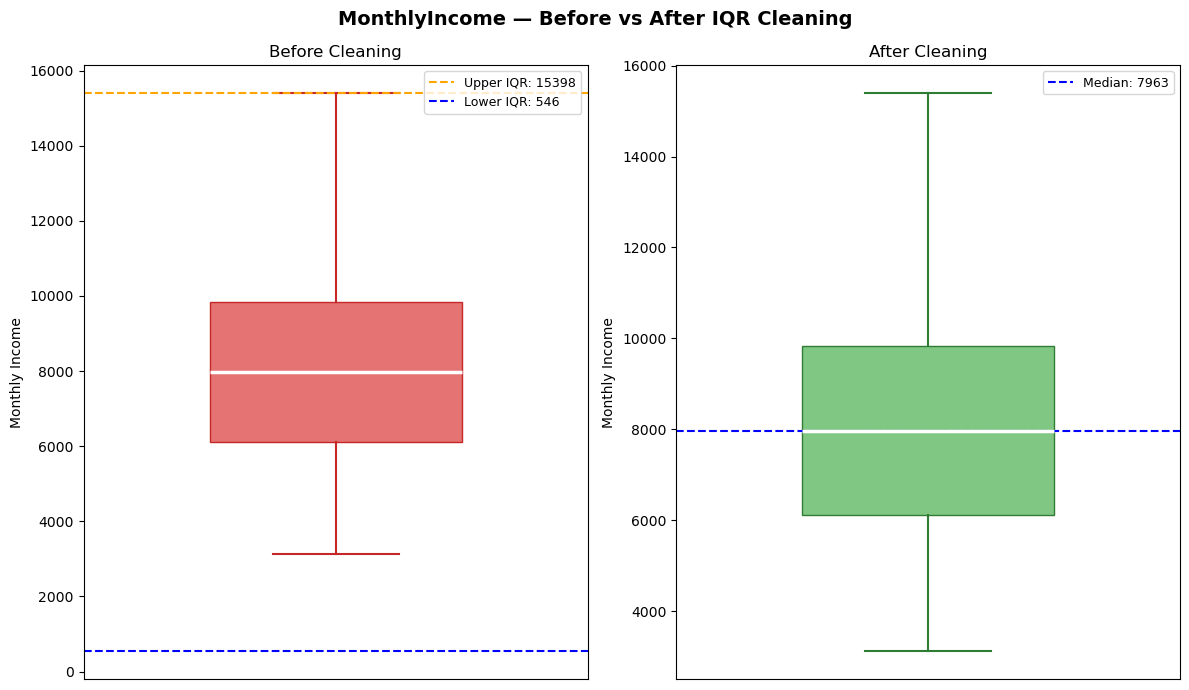

In [57]:
import matplotlib.pyplot as plt
import numpy as np

Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

lower = max(0, Q1 - 1.5 * IQR)
upper = Q3 + 1.5 * IQR

outliers_mask = (df['MonthlyIncome'] < lower) | (df['MonthlyIncome'] > upper)
outliers = outliers_mask.sum()
outlier_values = df['MonthlyIncome'][outliers_mask]

original = df['MonthlyIncome'].copy()

df['MonthlyIncome'] = df['MonthlyIncome'].clip(lower=lower, upper=upper)
income_median = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(income_median).round(2)

print(f"IQR range: {lower:.2f} — {upper:.2f}")
print(f"Outliers capped: {outliers}")
print(f"Missing filled with median: {income_median:.2f}")

# --- box plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
fig.suptitle('MonthlyIncome — Before vs After IQR Cleaning', fontsize=14, fontweight='bold')

# Before — full scale so outliers are visible
bp1 = axes[0].boxplot(original.dropna(), patch_artist=True,
                widths=0.5,
                boxprops=dict(facecolor='#e57373', color='#c62828'),
                medianprops=dict(color='white', linewidth=2.5),
                flierprops=dict(marker='o', markerfacecolor='#c62828',
                                markeredgecolor='#c62828', markersize=6, alpha=0.7),
                whiskerprops=dict(color='#c62828', linewidth=1.5),
                capprops=dict(color='#c62828', linewidth=1.5))
axes[0].set_title('Before Cleaning', fontsize=12)
axes[0].set_ylabel('Monthly Income')
axes[0].set_xticks([])

# draw IQR boundary lines
axes[0].axhline(upper, color='orange', linestyle='--', linewidth=1.5, label=f'Upper IQR: {upper:.0f}')
axes[0].axhline(lower, color='blue',   linestyle='--', linewidth=1.5, label=f'Lower IQR: {lower:.0f}')

# annotate outlier dots with their values
for val in outlier_values:
    axes[0].annotate(f'{val:,.0f}',
                     xy=(1, val),
                     xytext=(1.15, val),
                     fontsize=7,
                     color='#c62828',
                     va='center',
                     arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

axes[0].legend(fontsize=9)

# After
bp2 = axes[1].boxplot(df['MonthlyIncome'].dropna(), patch_artist=True,
                widths=0.5,
                boxprops=dict(facecolor='#81c784', color='#2e7d32'),
                medianprops=dict(color='white', linewidth=2.5),
                flierprops=dict(marker='o', markerfacecolor='#2e7d32',
                                markeredgecolor='#2e7d32', markersize=6, alpha=0.7),
                whiskerprops=dict(color='#2e7d32', linewidth=1.5),
                capprops=dict(color='#2e7d32', linewidth=1.5))
axes[1].set_title('After Cleaning', fontsize=12)
axes[1].set_ylabel('Monthly Income')
axes[1].set_xticks([])
axes[1].axhline(income_median, color='blue', linestyle='--',
                linewidth=1.5, label=f'Median: {income_median:.0f}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Fix negative YearsAtCompany 


In [58]:
neg = (df['YearsAtCompany'] < 0).sum()
df['YearsAtCompany'] = df['YearsAtCompany'].abs()
print(f"YearsAtCompany — {neg} negative values converted to absolute")

YearsAtCompany — 291 negative values converted to absolute


## Fix SatisfactionScore: fill missing with median, cast to int 


In [59]:
sat_median = df['SatisfactionScore'].median()
df['SatisfactionScore'] = (
    df['SatisfactionScore'].fillna(sat_median).round(0).astype(int)
)
print(f"SatisfactionScore — missing filled with median ({int(sat_median)})")

SatisfactionScore — missing filled with median (3)


## Fix LastPromotionDate: parse, fix invalids, format as YYYY-MM-DD 


In [60]:
df['LastPromotionDate'] = pd.to_datetime(df['LastPromotionDate'], errors='coerce')
median_date = df['LastPromotionDate'].dropna().sort_values().iloc[
    len(df['LastPromotionDate'].dropna()) // 2
]
df['LastPromotionDate'] = df['LastPromotionDate'].fillna(median_date)
df['LastPromotionDate'] = df['LastPromotionDate'].dt.strftime('%Y-%m-%d')
print(f"LastPromotionDate — invalid dates fixed, formatted as YYYY-MM-DD")

LastPromotionDate — invalid dates fixed, formatted as YYYY-MM-DD


In [61]:
print(f"Final shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
df.head()

Final shape: (616, 8)
Missing values:
EmployeeID           0
Age                  0
Department           0
MonthlyIncome        0
YearsAtCompany       0
Attrition            0
LastPromotionDate    0
SatisfactionScore    0
dtype: int64


,EmployeeID,Age,Department,MonthlyIncome,YearsAtCompany,Attrition,LastPromotionDate,SatisfactionScore
0,1001,45,IT,4903.03,1,No,2022-12-29,5
1,1002,50,Sales,5947.48,8,Yes,2023-05-19,5
2,1003,45,HR,7963.07,26,No,2021-11-02,3
3,1004,45,Finance,7963.07,6,No,2021-11-28,3
4,1005,29,Finance,8342.33,12,No,2020-05-11,1


In [62]:
# --- Save clean file for Power BI ---
output_path = r'C:\Users\iions\Documents\New folder\dylitica _assignment\hr_attrition_clean_powerbi.csv'

df.to_csv(output_path, index=False)

print(f"File saved to: {output_path}")
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")

File saved to: C:\Users\iions\Documents\New folder\dylitica _assignment\hr_attrition_clean_powerbi.csv
Shape: (616, 8)

Column dtypes:
EmployeeID             int64
Age                    int64
Department            object
MonthlyIncome        float64
YearsAtCompany         int64
Attrition             object
LastPromotionDate     object
SatisfactionScore      int64
dtype: object
